## E-Commerce Analysis

**Required Library**

In [1]:
import urllib.parse
from sqlalchemy import create_engine
import time 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load DataSet**

In [2]:
df = pd.read_csv(r"C:\Users\dell\Downloads\messy_ecommerce_sales_data.csv")

In [3]:
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


In [4]:
# Copy first orginal Data
df_Clean = df.copy()

**Data Preaparing & Cleaning Process**

In [5]:
# Basic Informations
rows = df_Clean.shape[0]
columns = df_Clean.shape[1]
print(f'The Dataset have total number of {rows} rows & {columns} columns')

The Dataset have total number of 103 rows & 11 columns


In [6]:
# Information of data set
df_Clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    object 
 2   Order_ID        103 non-null    object 
 3   Order_Date      103 non-null    object 
 4    Product        103 non-null    object 
 5   Category        95 non-null     object 
 6   Quantity        98 non-null     object 
 7   Price           98 non-null     object 
 8   Payment_Method  103 non-null    object 
 9   Status          103 non-null    object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.0+ KB


In [7]:
# Reomove space on every column
df_Clean.columns = df_Clean.columns.str.strip()


In [8]:
for col in df_Clean.columns:
    print(df_Clean[col].value_counts())
    print("--"*60)

ID
146    2
175    2
142    2
100    1
104    1
      ..
195    1
196    1
197    1
198    1
199    1
Name: count, Length: 100, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Customer_Name
Customer_146    2
Customer_175    2
Customer_142    2
Customer_100    1
Customer_104    1
               ..
Customer_195    1
Customer_196    1
Customer_197    1
Customer_198    1
Customer_199    1
Name: count, Length: 100, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Order_ID
ORD-32755    2
ORD-56651    2
ORD-69018    2
ORD-41285    1
ORD-93614    1
            ..
ORD-82876    1
ORD-78384    1
ORD-79139    1
ORD-14608    1
ORD-82922    1
Name: count, Length: 100, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Order_Date
2025-02-09    4
2025-

In [9]:
for col in df_Clean.columns:
    print(df_Clean[col].unique())
    print("--"*60)

[100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153
 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171
 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189
 190 191 192 193 194 195 196 197 198 199]
------------------------------------------------------------------------------------------------------------------------
['Customer_100' 'Customer_101' 'Customer_102' 'Customer_103'
 'Customer_104' 'Customer_105' 'Customer_106' 'Customer_107'
 'Customer_108' 'Customer_109' 'Customer_110' 'Customer_111'
 'Customer_112' 'Customer_113' 'Customer_114' 'Customer_115'
 'Customer_116' 'Customer_117' 'Customer_118' 'Customer_119'
 'Customer_120' 'Customer_121' 'Customer_122' 'Customer_123'
 'Customer_124' 'Customer_125' 'Customer_126' 'Customer_127'
 'Customer_128' 'Customer_129' 'Customer_130'

In [10]:
# Fixing Categorical Issues
df_Clean['Product'].replace({'shoes':'Shoes'}, inplace=True)
(df_Clean['Category'].replace({'sports': 'Sports', 
"electronic": "Electronics", 'ELECTRONICS': 
'Electronics', 'electronics':'Electronics'},inplace=True))

In [11]:
#change data types & fix error
df_Clean['Quantity'] = df_Clean['Quantity'].str.replace("-", '',regex=False )
df_Clean['Quantity'] = df_Clean['Quantity'].str.extract('(\d+)')
df_Clean['Quantity'] = pd.to_numeric(df_Clean['Quantity'])


In [12]:
df_Clean['Price'] = df_Clean['Price'].str.extract('(\d+\.?\d*)')
df_Clean['Price'] = pd.to_numeric(df_Clean['Price'], errors= 'coerce')

In [13]:
# Check Duplicate Values
duplicate = df_Clean[df_Clean.duplicated()].shape[0]
print(f"Total Number of Duplicate Records: {duplicate}")

Total Number of Duplicate Records: 1


In [14]:
# remove dupplicate records
df_Clean.drop_duplicates(inplace=True)
duplicate = df_Clean[df_Clean.duplicated()].shape[0]
print(f"Total Number of Duplicate Records: {duplicate}")

Total Number of Duplicate Records: 0


In [15]:
# Check Missing & fill Values 
Null_Summary = pd.DataFrame({"Number of Null": df_Clean.isnull().sum(),
'Percentages': round((df_Clean.isnull().sum()/len(df_Clean))*100,2)})
Null_Summary 

,Number of Null,Percentages
ID,0,0.00
Customer_Name,0,0.00
Order_ID,0,0.00
Order_Date,0,0.00
Product,0,0.00
Category,8,7.84
Quantity,5,4.90
Price,8,7.84
Payment_Method,0,0.00
Status,0,0.00


In [16]:
Total_Null = round((df_Clean.isnull().sum().sum()/df_Clean.size)*100,2)
print(f'Overall total Null {Total_Null}%')

Overall total Null 3.12%


In [17]:
df_Clean['Category'].fillna(df_Clean['Category'].mode()[0],inplace=True)

In [18]:
# price fill
df_Clean['Price'] = df_Clean['Price'].fillna(df_Clean['Price'].median())
# quantity fill
df_Clean['Quantity'] = df_Clean['Quantity'].fillna(df_Clean['Quantity'].median())
df_Clean['Quantity'] = df_Clean['Quantity'].astype(int)
# total fill
df_Clean['Total'] = df_Clean['Total'].fillna(
    df_Clean['Price'] * df_Clean['Quantity']
)

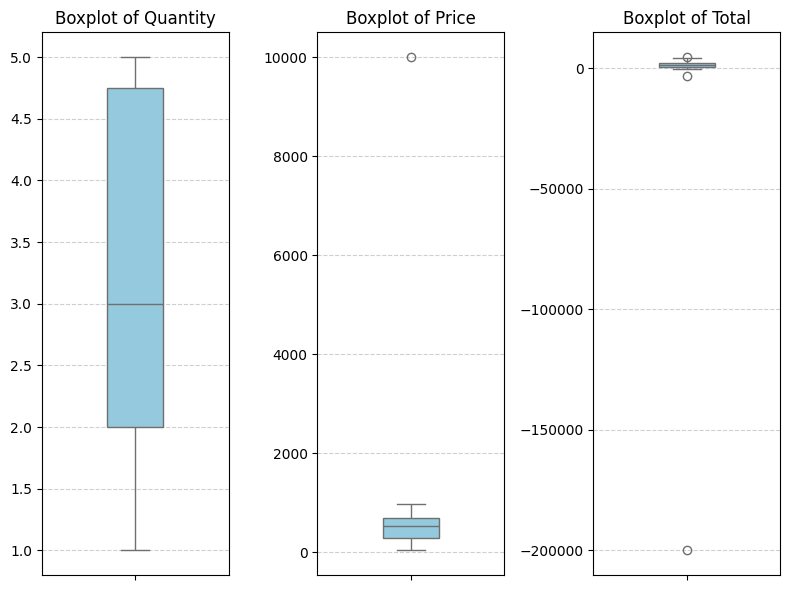

In [19]:
# check outlier & Handling Outlier
cols = ['Quantity','Price', 'Total']
plt.figure(figsize=(8,6))
for i, col in enumerate(cols,1):
    plt.subplot(1,3,i)
    sns.boxplot(y= df_Clean[col], color='skyblue', width=0.3)
    plt.title(f'Boxplot of {col}', fontsize = 12)
    plt.ylabel('')
    plt.grid(axis='y', linestyle = '--', alpha = 0.6)
plt.tight_layout()
plt.show()

In [20]:
demo = df_Clean[df_Clean['Price'] > 5000]
demo

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
17,117,Customer_117,ORD-72751,2025-02-12,Blender,Electronics,2,10000.0,Cash on Delivery,Processing,-200000.0


In [21]:
df_Clean['Total'] = np.abs(df_Clean['Total'])

In [22]:
df_Clean['Total'] = df_Clean['Price'] * df_Clean['Quantity']

In [23]:
(df_Clean['Total'] == df_Clean['Price'] * df_Clean['Quantity']).all()

np.True_

In [24]:
# Fix date Columns
df_Clean['Order_Date'] = pd.to_datetime(
    df_Clean['Order_Date'],
    errors='coerce',
    dayfirst=True
)


In [25]:
df_Clean = df_Clean.dropna(subset=['Order_Date'])

In [26]:
df_Clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 0 to 101
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              99 non-null     int64         
 1   Customer_Name   99 non-null     object        
 2   Order_ID        99 non-null     object        
 3   Order_Date      99 non-null     datetime64[ns]
 4   Product         99 non-null     object        
 5   Category        99 non-null     object        
 6   Quantity        99 non-null     int64         
 7   Price           99 non-null     float64       
 8   Payment_Method  99 non-null     object        
 9   Status          99 non-null     object        
 10  Total           99 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 9.3+ KB


## Load Clean DataSet in MySQL

In [27]:
username = "root"
raw_password = "ANku7970@!#"
password = urllib.parse.quote_plus(raw_password)

host = "localhost"
port = 3306
database = "Retail_Analysis"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

try:
   print("Attempting to connect to database...")
   for x in range(1,4):
      print(x)
      time.sleep(1)
   df_Clean.to_sql("df_clean",engine,
   if_exists="replace",index=False)
   print("Connected ✅ Data Loaded Successfully") 

except Exception as e:
   print("Not Connected❌")
   print("Reson",e)

Attempting to connect to database...
1
2
3
Connected ✅ Data Loaded Successfully


## Exploratory Data Analysis & Visualizations

In [28]:
df_Clean.describe()

,ID,Order_Date,Quantity,Price,Total
count,99.000000,99,99.000000,99.000000,99.000000
mean,149.656566,2025-05-02 07:01:49.090909184,3.090909,608.239596,1808.074141
min,100.000000,2023-01-05 00:00:00,1.000000,38.000000,40.950000
25%,125.500000,2025-02-09 00:00:00,2.000000,289.450000,702.555000
50%,150.000000,2025-05-19 00:00:00,3.000000,534.705000,1461.840000
75%,174.500000,2025-08-05 00:00:00,5.000000,701.065000,2563.130000
max,199.000000,2025-11-06 00:00:00,5.000000,10000.000000,20000.000000
std,28.739208,NaN,1.492094,985.996648,2173.944507


In [29]:
df_Clean.describe(include='object').T

,count,unique,top,freq
Customer_Name,99,97,Customer_142,2
Order_ID,99,97,ORD-69018,2
Product,99,20,Shoes,9
Category,99,5,Books,30
Payment_Method,99,4,Cash on Delivery,32
Status,99,5,Processing,26


**Distribution of Numberical Columns**

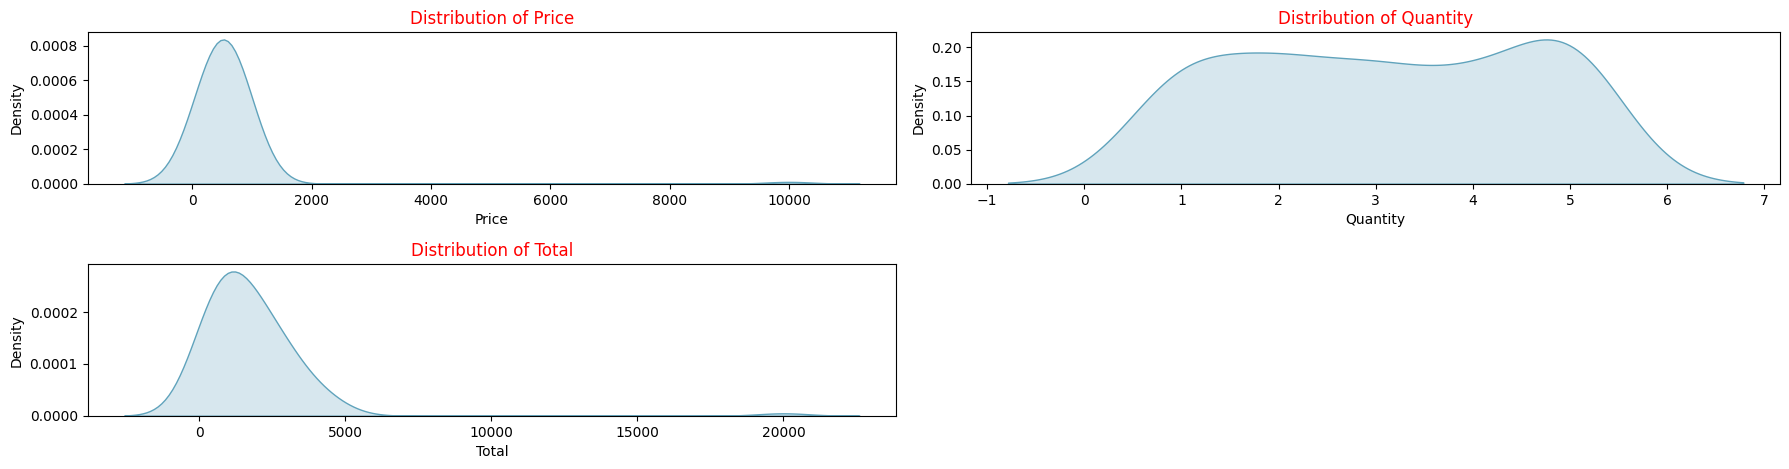

In [30]:
Num_column = ['Price','Quantity','Total']
plt.figure(figsize=(18,9))
for x, col in enumerate(Num_column):
    plt.subplot(4,2,x+1)
    sns.kdeplot(x = df_Clean[col],fill=True, color='#60a3bc')
    plt.title(f"Distribution of {col}", fontsize = 12,
    color = "red")
plt.tight_layout()
plt.show()

## Insight
**1. Price Distribution Insight**
- The distribution is right-skewed (positively skewed)
- Most values are concentrated in the low to mid range (0–1000)
- A few values extend up to 10,000 (high-end products)

**2. Quantity Distribution Insight**
- Values mostly lie between 1 to 5 units
- Distribution is relatively balanced (not heavily skewed)

**3. Total (Revenue) Distribution Insight**
- The distribution is right-skewed
- Most transactions are low to medium value
- A few transactions have very high total values

**Distribution of Categorical Columns**

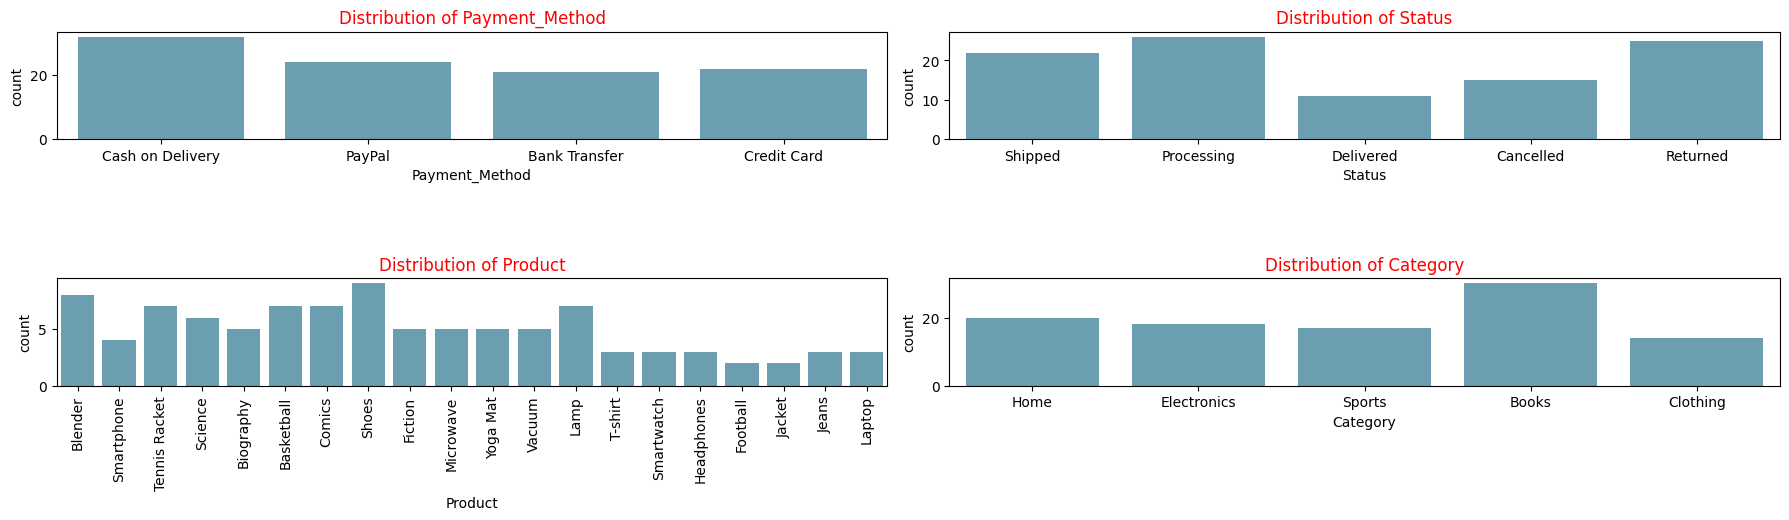

In [31]:
Categorical_column = ['Payment_Method','Status', "Product", "Category"]
plt.figure(figsize=(18,9))
for x, col in enumerate(Categorical_column):
    plt.subplot(4,2,x+1)
    sns.countplot(x=df_Clean[col],color='#60a3bc')
    plt.title(f"Distribution of {col}", fontsize = 12,
    color = "red")
    if col =='Product':
        plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

## Insights
**Payment Method**
- Cash on Delivery is the most preferred payment method, indicating that customers may have lower trust in online payment systems, which can impact digital payment adoption.

**Status**
- A high number of returned orders suggests potential issues in product quality or delivery, which may negatively affect customer satisfaction.

**Category**
- The Books category has the highest number of orders, indicating strong customer demand in this segment and making it a key revenue driver.

**Product**
- Product sales are relatively evenly distributed, suggesting that the business does not rely heavily on a single product, which reduces risk.

**Heatmap**

<Axes: >

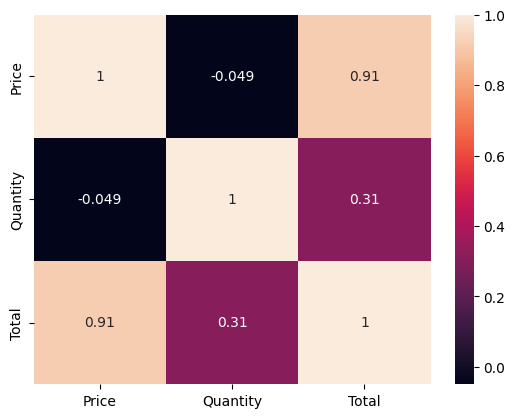

In [32]:
sns.heatmap(df_Clean[Num_column].corr(),annot=True)

## Insights
**1. Price vs Total → 0.91 (Strong Positive Correlation)**
- The correlation between Price and Total is very high (0.91). 
- This indicates that as the price increases, the total value of orders also increases significantly. 
- This suggests that price is the primary driver of revenue.

**2. Quantity vs Total → 0.31 (Moderate Positive Correlation)**
- The correlation between Quantity and Total is moderate (0.31). 
- This indicates that increasing quantity has some impact on total revenue, but not as strong as price. 
- This suggests that bulk purchases contribute to revenue, but are not the main driver.

**3. Price vs Quantity → -0.049 (Almost No Correlation)**
- The correlation between Price and Quantity is very weak (-0.049). 
- This indicates that price does not significantly influence the quantity purchased. 
- This suggests that customers' buying quantity is independent of product pricing.

**Product Revenue Analysis**

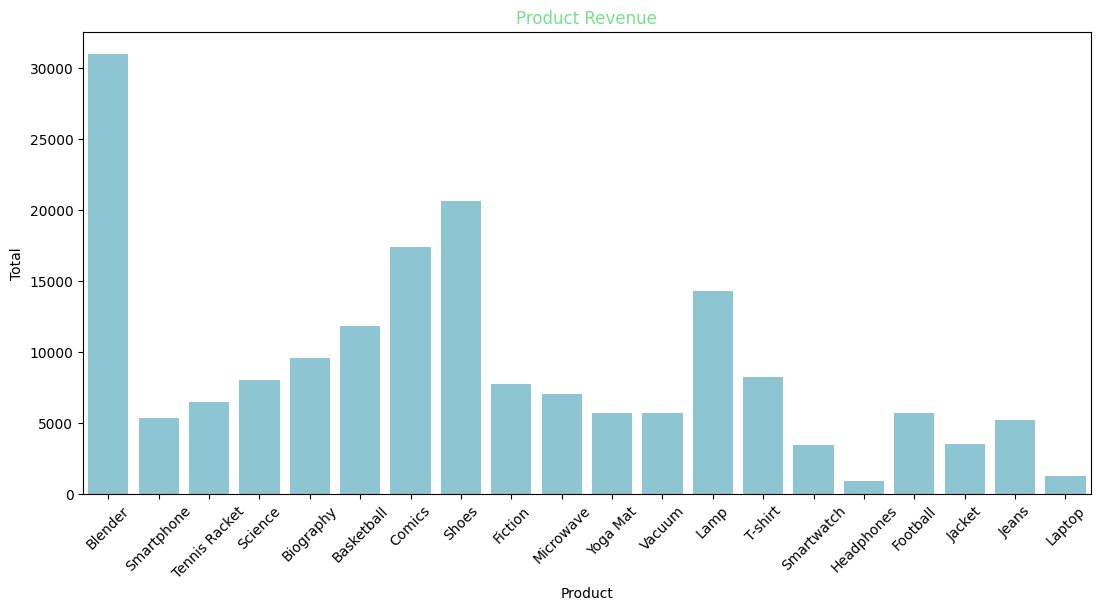

Insights
--------------------------------------------------------------------------------------------------------------------------------------------
The analysis shows that revenue is unevenly distributed across products,
with a few items like Blender, Shoes, and Comics generating the highest 
sales. This indicates that the business relies on a small number of 
high-performing products for major revenue. Meanwhile,
some products such as Headphones, Laptop, and Smartwatch contribute very little,
suggesting lower demand or fewer transactions. Overall, the product portfolio is diversified,
but improving underperforming products can help increase total revenue.
--------------------------------------------------------------------------------------------------------------------------------------------


In [33]:
Product_Revenue = pd.read_sql("Select Product, sum(Total) as " \
"Total from df_clean group by Product",engine)
plt.figure(figsize=(13,6))
sns.barplot(x=Product_Revenue["Product"], y= Product_Revenue["Total"],
color= "#82ccdd")
plt.title('Product Revenue',fontsize = 12, color = '#78e08f')
plt.xticks(rotation = 45)
plt.show()
print("Insights")
print("--"*70)
print("""The analysis shows that revenue is unevenly distributed across products,
with a few items like Blender, Shoes, and Comics generating the highest 
sales. This indicates that the business relies on a small number of 
high-performing products for major revenue. Meanwhile,
some products such as Headphones, Laptop, and Smartwatch contribute very little,
suggesting lower demand or fewer transactions. Overall, the product portfolio is diversified,
but improving underperforming products can help increase total revenue.""")
print('--'*70)

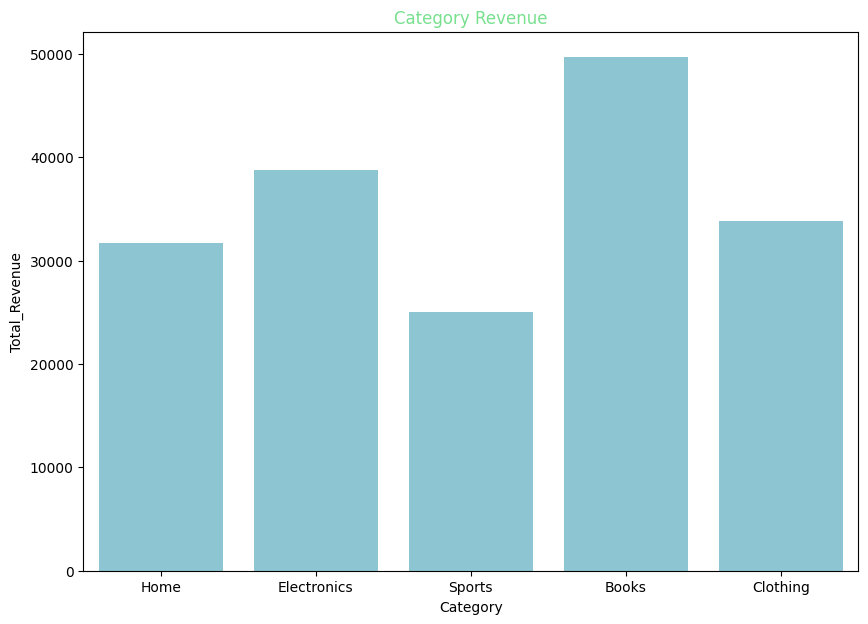

Insights
--------------------------------------------------------------------------------------------------------------------------------------------
The analysis shows that the Books category generates the highest revenue,
followed by Electronics and Clothing, indicating strong customer demand in these segments.
In contrast, Sports contributes the least revenue, suggesting lower demand or fewer sales.
Overall, revenue is uneven across categories, highlighting that focusing on high-performing 
categories like Books can drive business growth, while low-performing categories may
need improvement strategies.
--------------------------------------------------------------------------------------------------------------------------------------------


In [34]:
Category_Revenue = pd.read_sql('Select Category, sum(Total) as ' \
'Total_Revenue from df_clean group by Category',engine)
plt.figure(figsize=(10,7))
sns.barplot(x="Category", y = "Total_Revenue", 
data= Category_Revenue,color='#82ccdd')
plt.title("Category Revenue", fontsize =12,
color = "#78e08f")
plt.show()
print("Insights")
print("--"*70)
print('''The analysis shows that the Books category generates the highest revenue,
followed by Electronics and Clothing, indicating strong customer demand in these segments.
In contrast, Sports contributes the least revenue, suggesting lower demand or fewer sales.
Overall, revenue is uneven across categories, highlighting that focusing on high-performing 
categories like Books can drive business growth, while low-performing categories may
need improvement strategies.''')
print("--"*70)

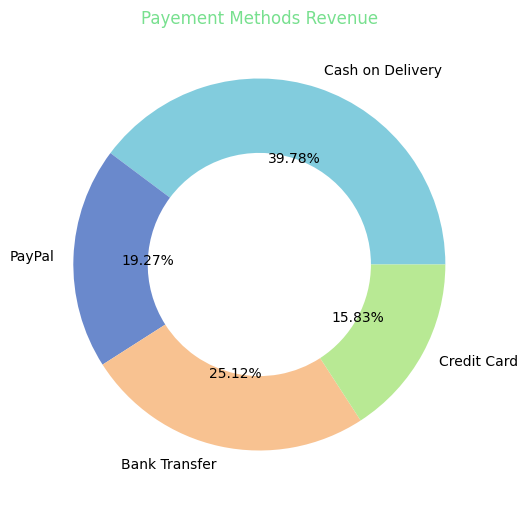

Insights
--------------------------------------------------------------------------------------------------------------------------------------------
The analysis shows that Cash on Delivery is the most preferred payment method,
accounting for nearly '40%' of transactions, indicating a strong customer preference for 
cash-based payments. Bank Transfer and PayPal have moderate usage, while Credit Card is 
the least used. This suggests that customers may have lower trust in online payment methods,
which could limit digital payment adoption.
--------------------------------------------------------------------------------------------------------------------------------------------


In [35]:
Method_Revenue = pd.read_sql("Select Payment_Method, sum(Total) as " \
"Total_Revenue from df_clean group by Payment_Method",engine)
plt.figure(figsize=(6,7))
plt.pie(Method_Revenue['Total_Revenue'], labels= Method_Revenue['Payment_Method'],
autopct="%1.2f%%",colors=["#82ccdd","#6a89cc","#f8c291","#b8e994"],
wedgeprops={'width':0.4})
plt.title('Payement Methods Revenue', fontsize = 12, color = "#78e08f")
plt.show()
print("Insights")
print('--'*70)
print('''The analysis shows that Cash on Delivery is the most preferred payment method,
accounting for nearly '40%' of transactions, indicating a strong customer preference for 
cash-based payments. Bank Transfer and PayPal have moderate usage, while Credit Card is 
the least used. This suggests that customers may have lower trust in online payment methods,
which could limit digital payment adoption.''')
print('--'*70)


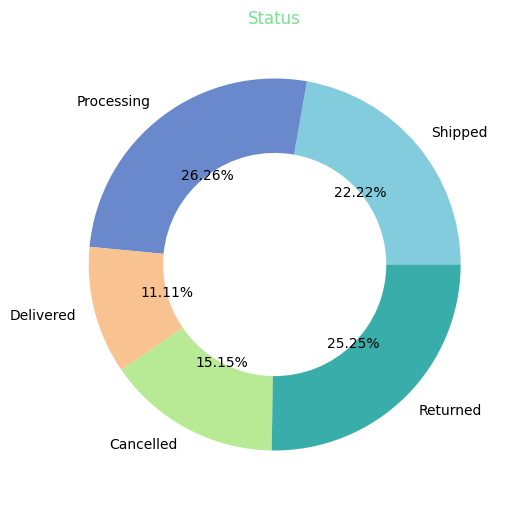

Insight
--------------------------------------------------------------------------------------------------------------------------------------------
The analysis shows that Processing (26.26%) and Returned (25.25%) 
orders make up the largest share, while Delivered orders are significantly 
lower (11.11%). This indicates potential inefficiencies in order completion and a 
high return rate, which may negatively impact customer
satisfaction and overall business performance.
--------------------------------------------------------------------------------------------------------------------------------------------


In [36]:
Status = pd.read_sql("Select Status, count(Status) as Status_Count from df_clean group by Status", engine)
plt.figure(figsize=(6,7))
plt.pie(Status['Status_Count'], labels= Status['Status'],
autopct="%1.2f%%",colors=["#82ccdd","#6a89cc","#f8c291"
,"#b8e994","#38ada9"],wedgeprops={'width':0.4})
plt.title('Status', fontsize = 12, color = "#78e08f")
plt.show()
print("Insight")
print('--'*70)
print('''The analysis shows that Processing (26.26%) and Returned (25.25%) 
orders make up the largest share, while Delivered orders are significantly 
lower (11.11%). This indicates potential inefficiencies in order completion and a 
high return rate, which may negatively impact customer
satisfaction and overall business performance.''')
print("--"*70)

**Time Based Analysis**

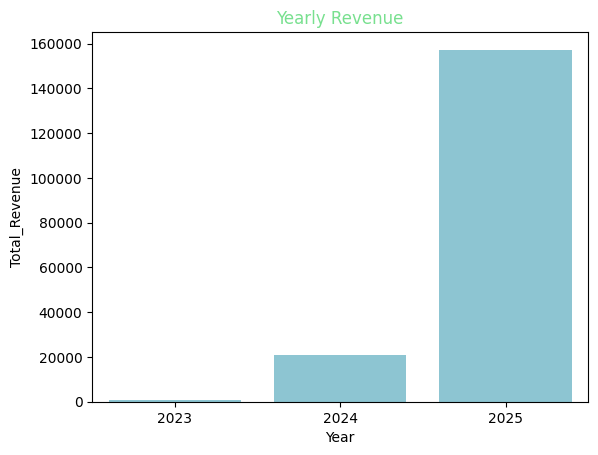

Insights
--------------------------------------------------------------------------------------------------------------------------------------------
The analysis shows a significant increase in revenue over the years, 
with a sharp rise in 2025 compared to 2023 and 2024. This indicates strong 
business growth and increasing sales performance over time.
--------------------------------------------------------------------------------------------------------------------------------------------


In [53]:
Yearly_Revenue = pd.read_sql("Select year(Order_Date) as Year ," \
"sum(Total) as Total_Revenue from df_clean group by Year", engine)
sns.barplot(y = 'Total_Revenue', x = 'Year', 
data = Yearly_Revenue,color='#82ccdd')
plt.title("Yearly Revenue", fontsize = 12, color = "#78e08f")
plt.show()
print('Insights')
print('--'*70)
print('''The analysis shows a significant increase in revenue over the years, 
with a sharp rise in 2025 compared to 2023 and 2024. This indicates strong 
business growth and increasing sales performance over time.''')
print("--"*70)

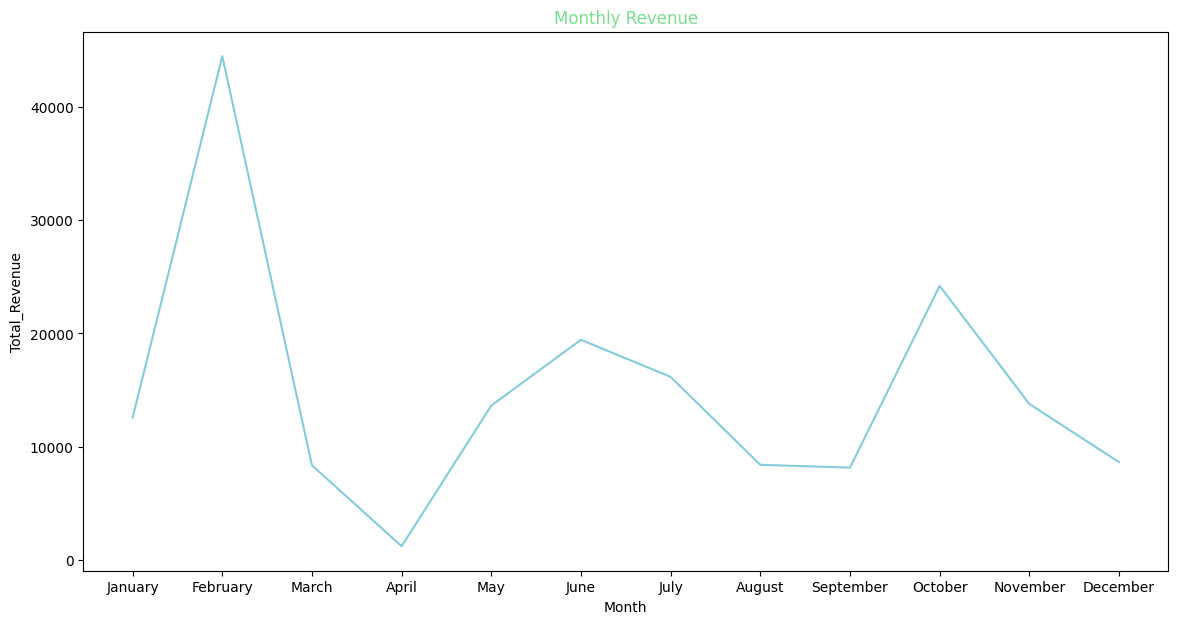

Insights
--------------------------------------------------------------------------------------------------------------------------------------------
The analysis shows that revenue fluctuates significantly across months, 
with a sharp peak in February and another high in October, while April records 
the lowest revenue. This indicates seasonal variations in sales, where certain months 
perform exceptionally well while others experience lower demand.
--------------------------------------------------------------------------------------------------------------------------------------------


In [67]:
Monthly_Revenue = pd.read_sql("Select MonthName(Order_Date) as Month, MONTH(Order_Date) AS Month_Num," \
"sum(Total) as Total_Revenue from df_clean group by Month,Month_Num order by Month_Num",engine)
Monthly_Revenue
plt.figure(figsize=(14,7))
sns.lineplot(x = "Month", y = "Total_Revenue", 
data=Monthly_Revenue,color="#82ccdd")
plt.title("Monthly Revenue", fontsize = 12, color = "#78e08f")
plt.show()
print("Insights")
print("--"*70)
print("""The analysis shows that revenue fluctuates significantly across months, 
with a sharp peak in February and another high in October, while April records 
the lowest revenue. This indicates seasonal variations in sales, where certain months 
perform exceptionally well while others experience lower demand.""")
print("--"*70)

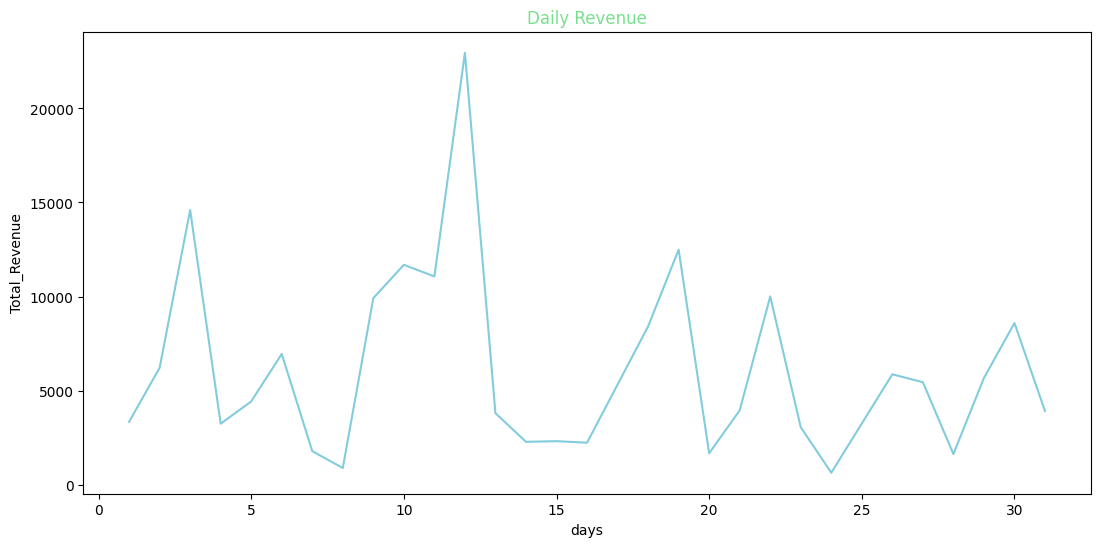

Insights
--------------------------------------------------------------------------------------------------------------------------------------------
The daily revenue shows high fluctuations, with a sharp peak 
around mid-month and several low-performing days. This indicates inconsistent 
sales performance on a day-to-day basis, where a few days contribute 
significantly more revenue than others.
--------------------------------------------------------------------------------------------------------------------------------------------


In [71]:
Daily_Revenue = pd.read_sql("Select day(Order_date) as days, " \
"sum(Total) as Total_Revenue from df_clean group by days order by days", engine)
plt.figure(figsize=(13,6))
sns.lineplot(x = "days",y="Total_Revenue",
data=Daily_Revenue, color = "#82ccdd")
plt.title("Daily Revenue", fontsize =12, color ="#78e08f")
plt.show()
print('Insights')
print("--"*70)
print("""The daily revenue shows high fluctuations, with a sharp peak 
around mid-month and several low-performing days. This indicates inconsistent 
sales performance on a day-to-day basis, where a few days contribute 
significantly more revenue than others.""")
print("--"*70)
